In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# Connessione al database
BASE_DIR = os.path.dirname(os.path.abspath(''))
DB_PATH = os.path.join(BASE_DIR, 'db', 'nuclear.db')
conn = sqlite3.connect(DB_PATH)

# Stile grafici
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Setup completato")
print(f"Database: {DB_PATH}")

Setup completato
Database: C:\Users\giuse\Documents\nuclear-data-analysis\db\nuclear.db


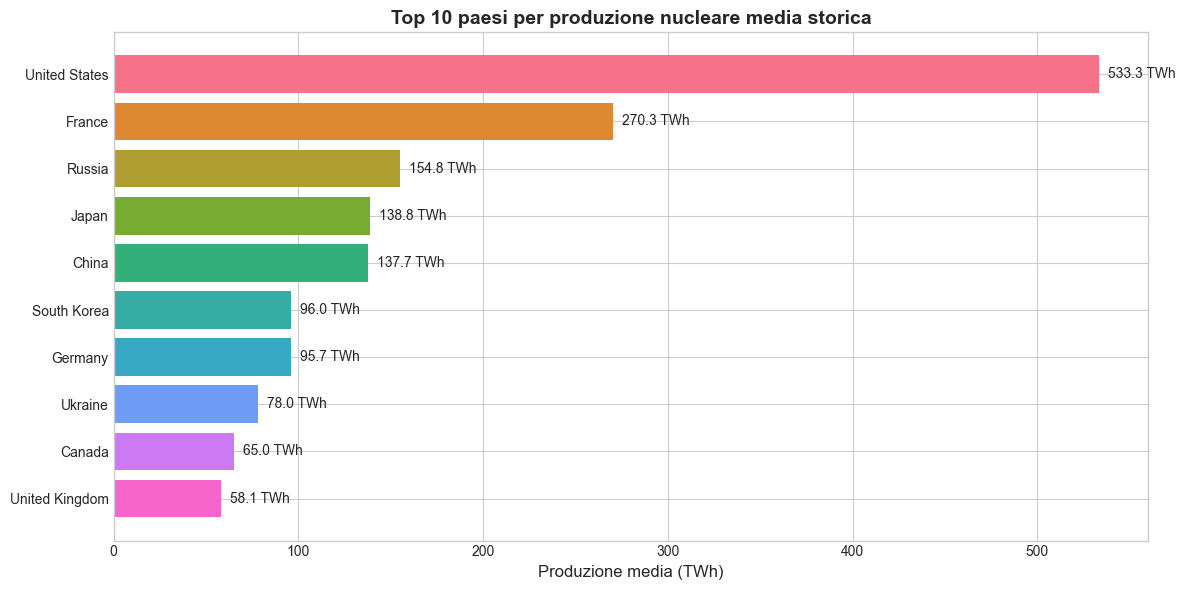

Grafico salvato in plots/


In [2]:
# Leggi i dati dal database con una query SQL
query = """
    SELECT country, ROUND(AVG(nuclear_twh), 1) as media_twh
    FROM nuclear_generation
    WHERE nuclear_twh > 0
    GROUP BY country
    ORDER BY media_twh DESC
    LIMIT 10
"""
df_top10 = pd.read_sql(query, conn)

# Grafico
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_top10['country'], df_top10['media_twh'], 
               color=sns.color_palette('husl', 10))

# Etichette valori sulle barre
for bar, val in zip(bars, df_top10['media_twh']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} TWh', va='center', fontsize=10)

ax.set_xlabel('Produzione media (TWh)', fontsize=12)
ax.set_title('Top 10 paesi per produzione nucleare media storica', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/01_top10_produttori.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

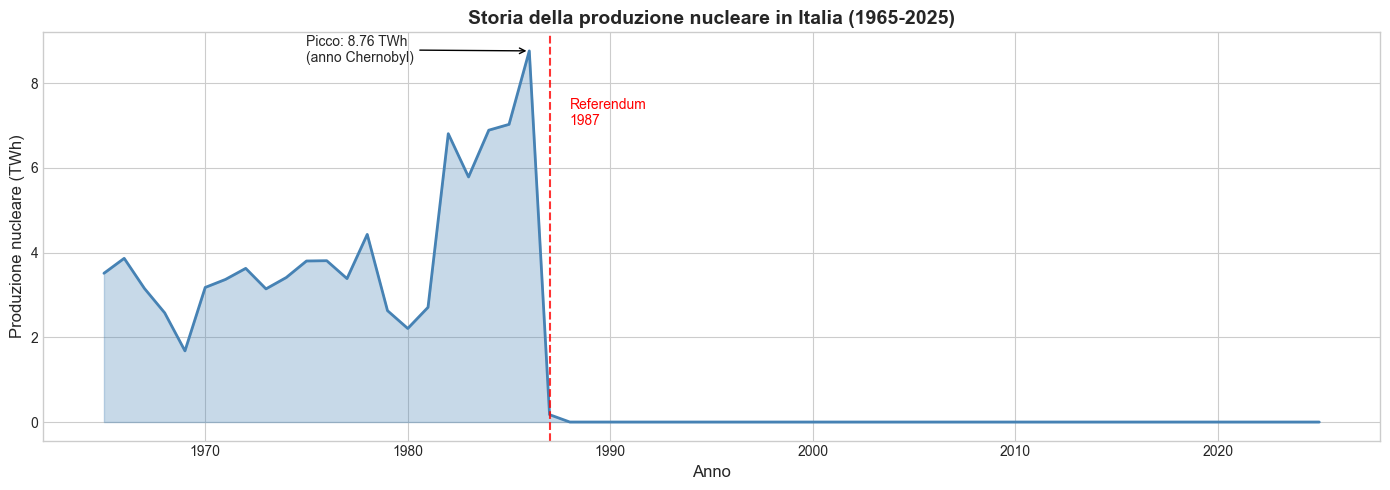

Grafico salvato in plots/


In [3]:
query = """
    SELECT year, nuclear_twh
    FROM nuclear_generation
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_italy['year'], df_italy['nuclear_twh'], 
                alpha=0.3, color='steelblue')
ax.plot(df_italy['year'], df_italy['nuclear_twh'], 
        color='steelblue', linewidth=2)

# Linea verticale referendum
ax.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1988, 7, 'Referendum\n1987', color='red', fontsize=10)

# Punto picco
ax.annotate('Picco: 8.76 TWh\n(anno Chernobyl)',
            xy=(1986, 8.758), xytext=(1975, 8.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Storia della produzione nucleare in Italia (1965-2025)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/02_italia_storia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

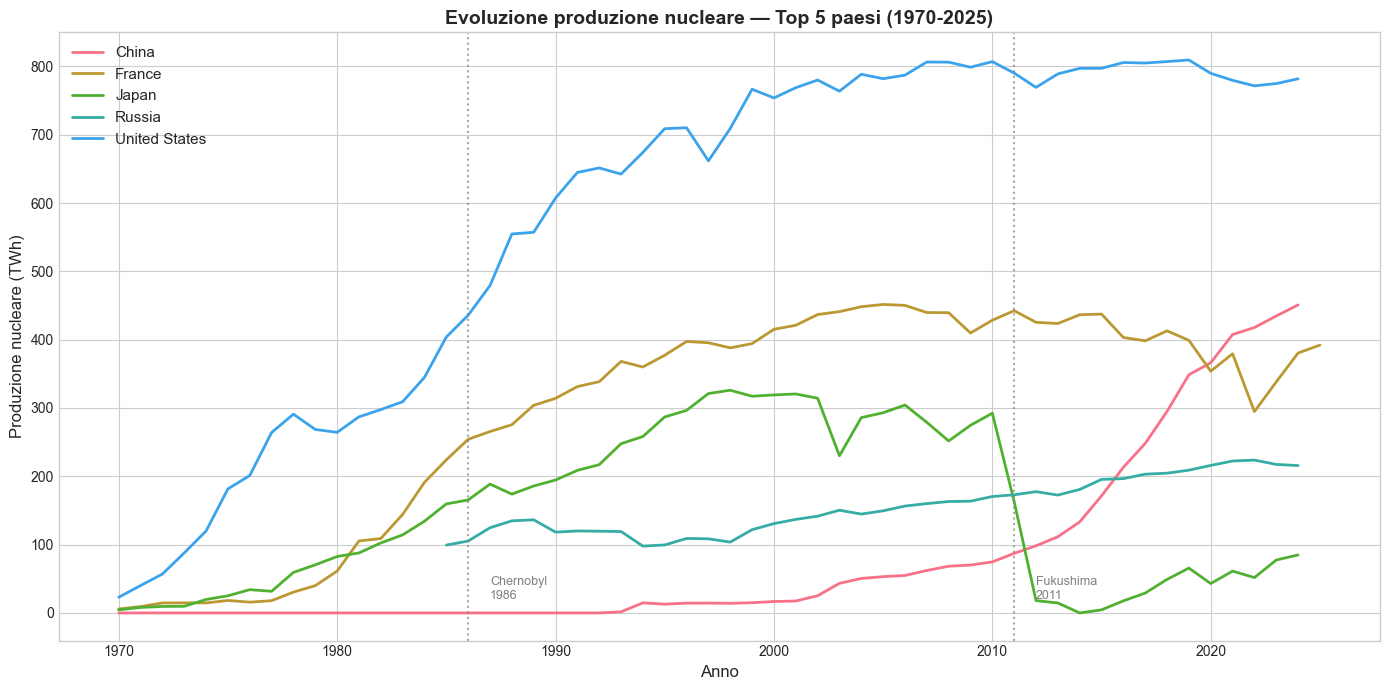

Grafico salvato in plots/


In [4]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('United States', 'France', 'Russia', 'China', 'Japan')
    AND year >= 1970
    ORDER BY country, year
"""
df_trend = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 7))

for country in df_trend['country'].unique():
    df_c = df_trend[df_trend['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], linewidth=2, label=country)

# Linea Chernobyl
ax.axvline(x=1986, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987, 20, 'Chernobyl\n1986', color='gray', fontsize=9)

# Linea Fukushima
ax.axvline(x=2011, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 20, 'Fukushima\n2011', color='gray', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Evoluzione produzione nucleare — Top 5 paesi (1970-2025)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/03_trend_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [5]:
query = """
    SELECT year, nuclear_electricity, nuclear_share_elec, 
           nuclear_share_energy, population
    FROM nuclear_indicators
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy_ind = pd.read_sql(query, conn)

print(f"Anni disponibili: {df_italy_ind['year'].min()} - {df_italy_ind['year'].max()}")
print(f"Righe totali: {len(df_italy_ind)}")
print("\nPrime righe con dati non nulli:")
print(df_italy_ind[df_italy_ind['nuclear_share_elec'].notna()].head(10))

Anni disponibili: 1900 - 2025
Righe totali: 126

Prime righe con dati non nulli:
    year  nuclear_electricity  nuclear_share_elec  nuclear_share_energy  \
85  1985                7.024               3.782                 1.197   
86  1986                8.758               4.554                 1.453   
87  1987                0.174               0.086                 0.028   
88  1988                0.000               0.000                 0.000   
89  1989                0.000               0.000                 0.000   
90  1990                0.000               0.000                 0.000   
91  1991                0.000               0.000                 0.000   
92  1992                0.000               0.000                 0.000   
93  1993                0.000               0.000                 0.000   
94  1994                0.000               0.000                 0.000   

    population  
85  56855499.0  
86  56875982.0  
87  56891919.0  
88  56928748.0  
89  5697

In [6]:
# Rileggiamo il CSV completo perché contiene tutte le fonti energetiche
df_owid = pd.read_csv('../data/raw/owid-energy-data.csv')

# Filtriamo solo l'Italia
cols_italia = ['year', 'nuclear_electricity', 'coal_electricity', 
               'gas_electricity', 'oil_electricity', 'hydro_electricity',
               'solar_electricity', 'wind_electricity', 
               'renewables_electricity', 'electricity_generation']

df_it = df_owid[df_owid['country'] == 'Italy'][cols_italia].copy()
df_it = df_it[df_it['year'] >= 1965].sort_values('year')

print(f"Anni disponibili: {df_it['year'].min()} - {df_it['year'].max()}")
print(f"\nPrime righe:")
print(df_it[df_it['electricity_generation'].notna()].head(10))

Anni disponibili: 1965 - 2025

Prime righe:
       year  nuclear_electricity  coal_electricity  gas_electricity  \
10345  1985                7.024            30.023           24.712   
10346  1986                8.758            31.004           26.871   
10347  1987                0.174            33.035           31.732   
10348  1988                0.000            33.897           32.420   
10349  1989                0.000            31.867           34.407   
10350  1990                0.000            32.050           39.710   
10351  1991                0.000            28.500           36.340   
10352  1992                0.000            21.360           35.480   
10353  1993                0.000            16.660           39.960   
10354  1994                0.000            19.860           40.800   

       oil_electricity  hydro_electricity  solar_electricity  \
10345           76.174             41.092              0.000   
10346           77.483             41.096     

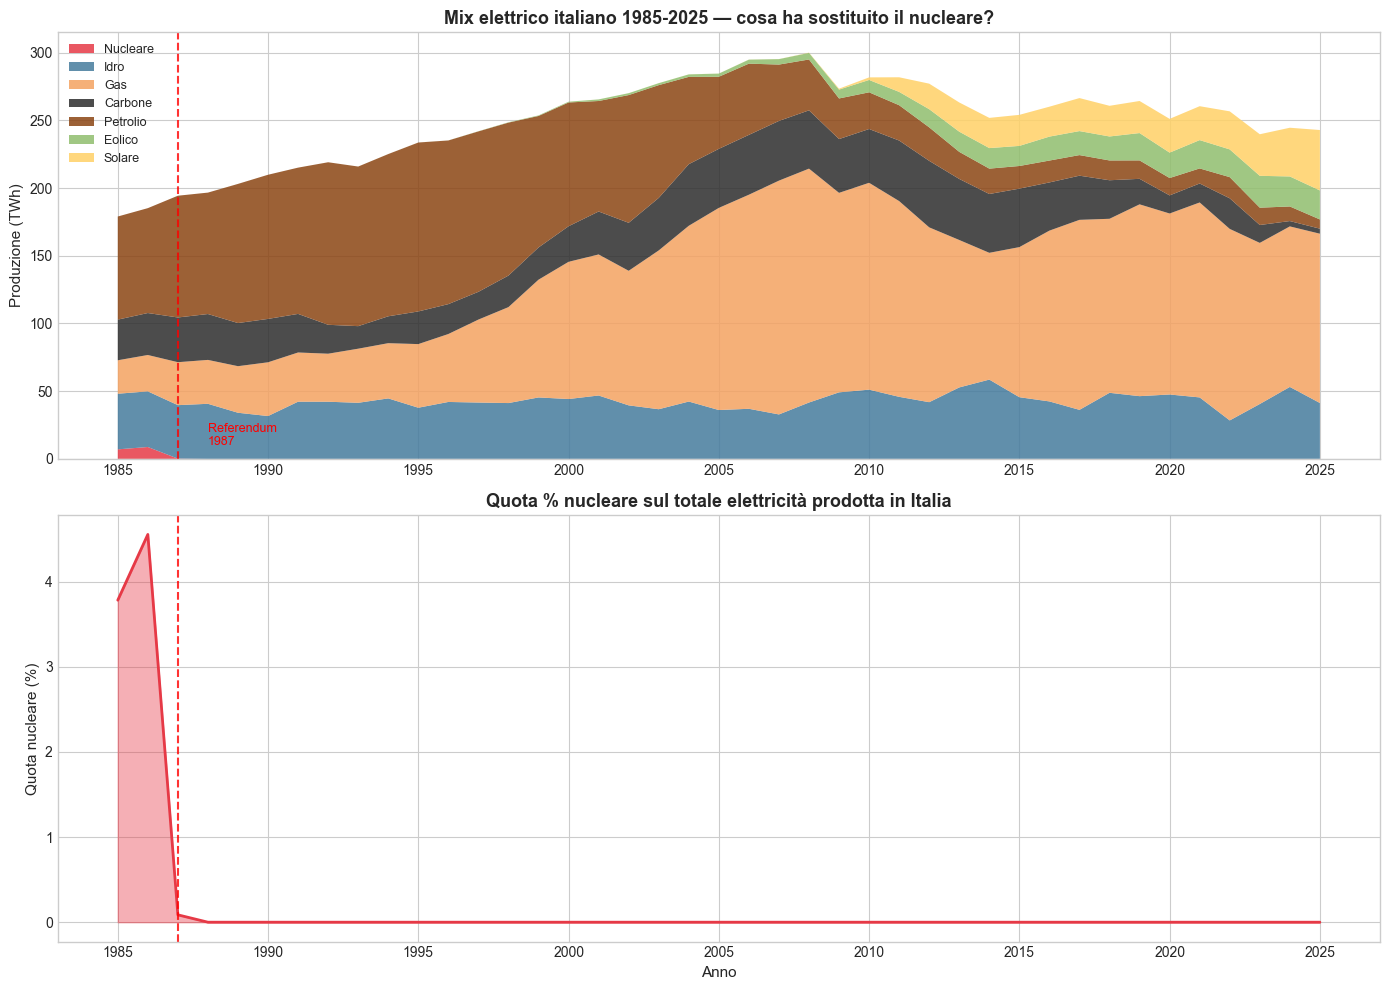

Grafico salvato in plots/


In [7]:
df_plot = df_it[df_it['electricity_generation'].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Grafico superiore: area chart mix energetico ---
ax1 = axes[0]

ax1.stackplot(df_plot['year'],
              df_plot['nuclear_electricity'].fillna(0),
              df_plot['hydro_electricity'].fillna(0),
              df_plot['gas_electricity'].fillna(0),
              df_plot['coal_electricity'].fillna(0),
              df_plot['oil_electricity'].fillna(0),
              df_plot['wind_electricity'].fillna(0),
              df_plot['solar_electricity'].fillna(0),
              labels=['Nucleare', 'Idro', 'Gas', 'Carbone', 'Petrolio', 'Eolico', 'Solare'],
              colors=['#e63946', '#457b9d', '#f4a261', '#2d2d2d', '#8B4513', '#90be6d', '#ffd166'],
              alpha=0.85)

ax1.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(1988, 10, 'Referendum\n1987', color='red', fontsize=9)
ax1.set_ylabel('Produzione (TWh)', fontsize=11)
ax1.set_title('Mix elettrico italiano 1985-2025 — cosa ha sostituito il nucleare?', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# --- Grafico inferiore: quota % nucleare ---
ax2 = axes[1]

# Calcola quota nucleare sul totale
df_plot['quota_nucleare'] = (df_plot['nuclear_electricity'].fillna(0) / 
                              df_plot['electricity_generation'] * 100)

ax2.fill_between(df_plot['year'], df_plot['quota_nucleare'],
                 alpha=0.4, color='#e63946')
ax2.plot(df_plot['year'], df_plot['quota_nucleare'],
         color='#e63946', linewidth=2)
ax2.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('Quota nucleare (%)', fontsize=11)
ax2.set_title('Quota % nucleare sul totale elettricità prodotta in Italia', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/02b_italia_mix_energetico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [8]:
query = """
    SELECT 
        CASE WHEN year <= 1987 THEN 'Prima (1985-1987)' 
             WHEN year >= 2000 THEN 'Dopo (2000-2010)'
             ELSE NULL END as periodo,
        ROUND(AVG(nuclear_twh), 2) as media_nucleare
    FROM nuclear_generation
    WHERE country = 'Italy'
    AND (year <= 1987 OR (year >= 2000 AND year <= 2010))
    GROUP BY periodo
"""
df_confronto = pd.read_sql(query, conn)
print(df_confronto)

# Dal CSV OWID calcoliamo la crescita del gas
gas_prima = df_it[df_it['year'] <= 1987]['gas_electricity'].mean()
gas_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['gas_electricity'].mean()
oil_prima = df_it[df_it['year'] <= 1987]['oil_electricity'].mean()
oil_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['oil_electricity'].mean()

print(f"\nGas — prima: {gas_prima:.1f} TWh → dopo: {gas_dopo:.1f} TWh (+{gas_dopo-gas_prima:.1f} TWh)")
print(f"Petrolio — prima: {oil_prima:.1f} TWh → dopo: {oil_dopo:.1f} TWh (+{oil_dopo-oil_prima:.1f} TWh)")

             periodo  media_nucleare
0   Dopo (2000-2010)            0.00
1  Prima (1985-1987)            3.91

Gas — prima: 27.8 TWh → dopo: 136.8 TWh (+109.1 TWh)
Petrolio — prima: 81.2 TWh → dopo: 59.8 TWh (+-21.4 TWh)


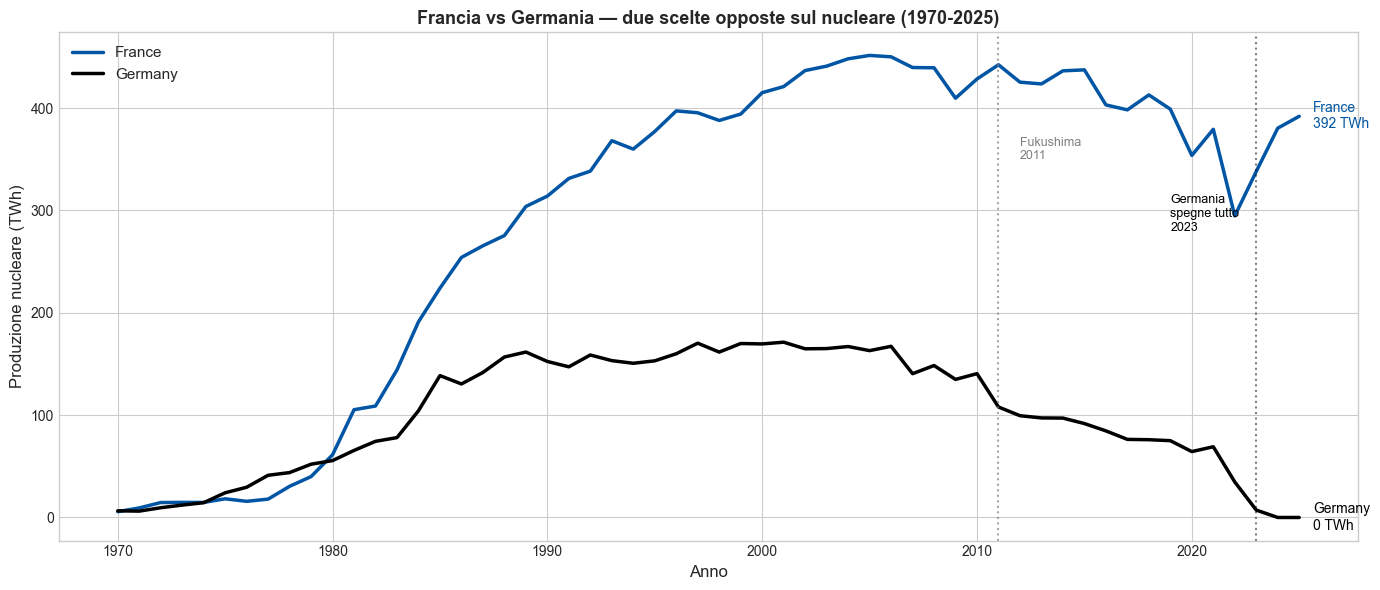

Grafico salvato in plots/


In [9]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('France', 'Germany')
    AND year >= 1970
    ORDER BY country, year
"""
df_frvde = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in [('France', '#0055A4'), ('Germany', '#000000')]:
    df_c = df_frvde[df_frvde['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], 
            linewidth=2.5, label=country, color=color)
    # Etichetta finale
    last = df_c.iloc[-1]
    ax.annotate(f"{country}\n{last['nuclear_twh']:.0f} TWh",
                xy=(last['year'], last['nuclear_twh']),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, color=color, va='center')

# Evento Fukushima
ax.axvline(x=2011, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 350, 'Fukushima\n2011', color='gray', fontsize=9)

# Evento Energiewende Germania
ax.axvline(x=2023, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax.text(2019, 280, 'Germania\nspegne tutto\n2023', color='black', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Francia vs Germania — due scelte opposte sul nucleare (1970-2025)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/04_francia_vs_germania.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [10]:
query = """
    SELECT country, 
           ROUND(nuclear_share_elec, 2) as quota_1987
    FROM nuclear_indicators
    WHERE year = 1987
    AND nuclear_share_elec > 0
    ORDER BY quota_1987 ASC
"""
df_benchmark = pd.read_sql(query, conn)
print("Paesi con dati nucleare nel 1987:")
print(df_benchmark.to_string())

Paesi con dati nucleare nel 1987:
           country  quota_1987
0            Italy        0.09
1           Brazil        0.48
2         Pakistan        0.84
3            India        2.38
4     South Africa        4.05
5      Netherlands        5.20
6           Russia       11.91
7        Argentina       12.40
8           Canada       15.56
9          Czechia       17.20
10   United States       17.29
11         Ukraine       17.91
12  United Kingdom       18.28
13           Japan       26.23
14         Germany       26.62
15        Bulgaria       28.61
16           Spain       31.11
17         Finland       36.80
18         Hungary       36.93
19     Switzerland       38.24
20       Lithuania       40.36
21          Sweden       45.97
22          Taiwan       47.89
23        Slovakia       48.72
24     South Korea       48.99
25         Belgium       66.23
26          France       70.15


In [11]:
query = """
    SELECT country, 
           ROUND(nuclear_share_elec, 2) as quota_1986
    FROM nuclear_indicators
    WHERE year = 1986
    AND nuclear_share_elec > 0
    ORDER BY quota_1986 ASC
"""
df_benchmark = pd.read_sql(query, conn)
print("Paesi con quota nucleare nel 1986:")
print(df_benchmark.to_string())

Paesi con quota nucleare nel 1986:
           country  quota_1986
0           Brazil        0.07
1         Pakistan        1.63
2            India        2.48
3            Italy        4.55
4     South Africa        5.94
5      Netherlands        6.28
6          Czechia       10.15
7           Russia       10.51
8        Argentina       11.65
9           Canada       15.21
10         Ukraine       15.66
11   United States       16.29
12  United Kingdom       19.62
13           Japan       24.45
14         Germany       24.92
15         Hungary       26.47
16        Bulgaria       28.86
17           Spain       29.14
18         Finland       38.70
19     Switzerland       39.06
20     South Korea       40.63
21          Taiwan       43.22
22       Lithuania       44.08
23        Slovakia       48.48
24          Sweden       50.45
25         Belgium       67.14
26          France       70.02


In [12]:
query = """
    SELECT country, ROUND(nuclear_twh, 2) as twh_1986
    FROM nuclear_generation
    WHERE year = 1986
    AND nuclear_twh > 0
    ORDER BY twh_1986 ASC
"""
df_twh86 = pd.read_sql(query, conn)
print("Produzione assoluta nucleare nel 1986 (TWh):")
print(df_twh86.to_string())

Produzione assoluta nucleare nel 1986 (TWh):
           country  twh_1986
0           Brazil      0.14
1         Pakistan      0.53
2      Netherlands      4.22
3            India      5.02
4        Argentina      5.71
5          Czechia      6.15
6          Hungary      7.42
7            Italy      8.76
8     South Africa      8.80
9        Lithuania      9.88
10        Slovakia     11.72
11        Bulgaria     12.07
12         Finland     18.95
13     Switzerland     22.42
14          Taiwan     26.94
15     South Korea     28.31
16           Spain     37.46
17         Belgium     39.39
18         Ukraine     42.71
19  United Kingdom     59.08
20          Sweden     69.95
21          Canada     71.27
22          Russia    105.22
23         Germany    130.49
24           Japan    165.37
25          France    254.16
26   United States    435.83


In [13]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('Italy', 'South Africa', 'Hungary', 'Finland')
    AND year >= 1980
    ORDER BY country, year
"""
df_cf = pd.read_sql(query, conn)

# Verifica dati
for country in ['Italy', 'South Africa', 'Hungary', 'Finland']:
    df_c = df_cf[df_cf['country'] == country]
    print(f"{country}: {df_c['year'].min()}-{df_c['year'].max()} | "
          f"1986: {df_c[df_c['year']==1986]['nuclear_twh'].values[0]:.2f} TWh | "
          f"2023: {df_c[df_c['year']==2023]['nuclear_twh'].values[0]:.2f} TWh")

Italy: 1980-2025 | 1986: 8.76 TWh | 2023: 0.00 TWh
South Africa: 1980-2024 | 1986: 8.80 TWh | 2023: 8.10 TWh
Hungary: 1980-2025 | 1986: 7.42 TWh | 2023: 15.92 TWh
Finland: 1980-2025 | 1986: 18.95 TWh | 2023: 34.31 TWh


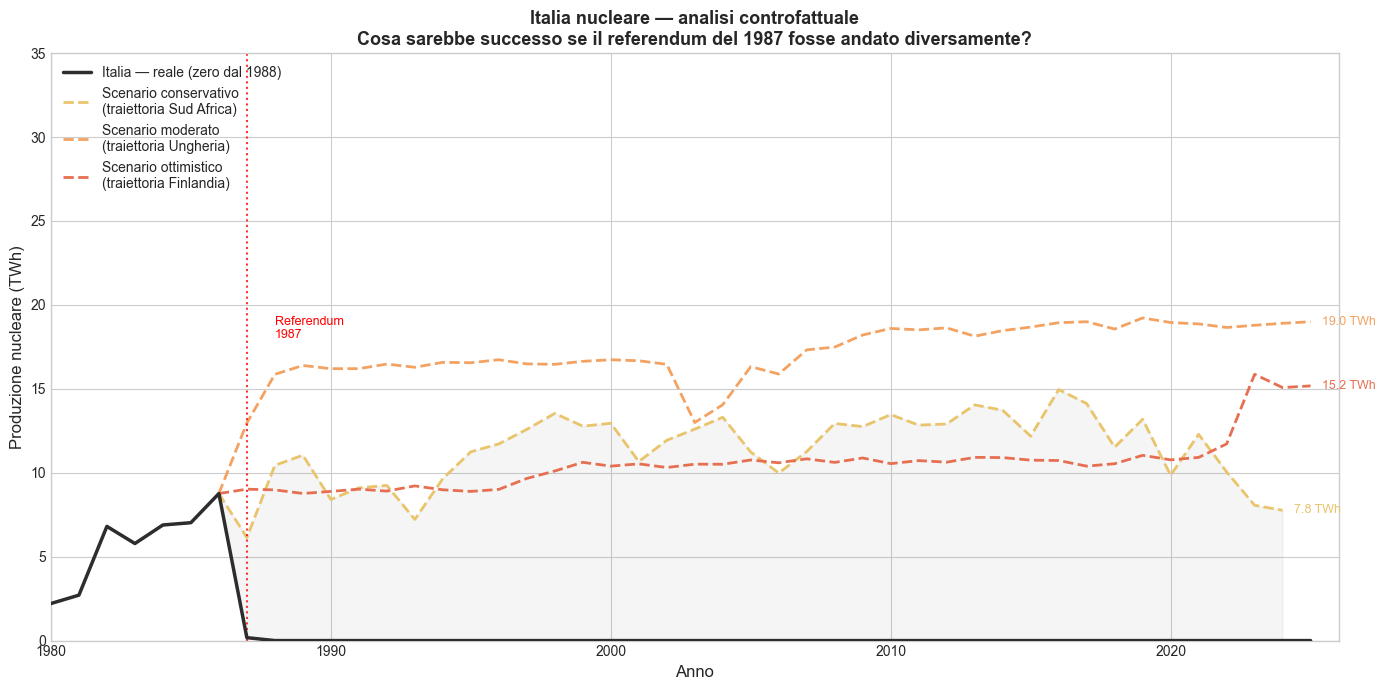

Grafico salvato in plots/


In [14]:
# Punto di partenza comune: Italia 1986
italy_1986 = 8.76

# Per ogni paese benchmark calcoliamo un fattore di scala
# rispetto al loro valore 1986, poi lo applichiamo all'Italia
benchmarks = {
    'South Africa': {'color': '#E9C46A', 'label': 'Scenario conservativo\n(traiettoria Sud Africa)'},
    'Hungary':      {'color': '#F4A261', 'label': 'Scenario moderato\n(traiettoria Ungheria)'},
    'Finland':      {'color': '#E76F51', 'label': 'Scenario ottimistico\n(traiettoria Finlandia)'},
}

fig, ax = plt.subplots(figsize=(14, 7))

# Linea reale Italia
df_italy = df_cf[df_cf['country'] == 'Italy']
ax.plot(df_italy['year'], df_italy['nuclear_twh'],
        color='#2d2d2d', linewidth=2.5, linestyle='-',
        label='Italia — reale (zero dal 1988)', zorder=5)

# Scenari controfattuali
for country, props in benchmarks.items():
    df_b = df_cf[df_cf['country'] == country].copy()
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    
    # Scala la traiettoria del benchmark partendo dal punto italiano
    df_b['twh_scalato'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    
    # Solo dal 1986 in poi
    df_b = df_b[df_b['year'] >= 1986]
    
    ax.plot(df_b['year'], df_b['twh_scalato'],
            color=props['color'], linewidth=2,
            linestyle='--', label=props['label'])
    
    # Etichetta valore finale
    last = df_b.iloc[-1]
    ax.annotate(f"{last['twh_scalato']:.1f} TWh",
                xy=(last['year'], last['twh_scalato']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

# Linea verticale referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(1988, 18, 'Referendum\n1987', color='red', fontsize=9)

# Area tra scenario conservativo e reale
df_sa = df_cf[df_cf['country'] == 'South Africa'].copy()
df_sa = df_sa[df_sa['year'] >= 1986]
b_1986_sa = 8.80
df_sa['twh_scalato'] = df_sa['nuclear_twh'] * (italy_1986 / b_1986_sa)
ax.fill_between(df_sa['year'], 
                df_italy[df_italy['year'] >= 1986]['nuclear_twh'].values[:len(df_sa)],
                df_sa['twh_scalato'],
                alpha=0.08, color='gray', label='_nolegend_')

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Italia nucleare — analisi controfattuale\nCosa sarebbe successo se il referendum del 1987 fosse andato diversamente?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1980, 2026)
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('../plots/05_italia_controfattuale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [17]:
# Ricreiamo df_paesi dal database
query = """
    SELECT country, iso_code, year, nuclear_twh
    FROM nuclear_generation
"""
df_paesi = pd.read_sql(query, conn)
print(f"df_paesi: {len(df_paesi)} righe")
print(df_paesi.head())

df_paesi: 8215 righe
       country iso_code  year  nuclear_twh
0  Afghanistan      AFG  2000          0.0
1  Afghanistan      AFG  2001          0.0
2  Afghanistan      AFG  2002          0.0
3  Afghanistan      AFG  2003          0.0
4  Afghanistan      AFG  2004          0.0


In [18]:
# Rileggiamo il CSV completo
df_owid_full = pd.read_csv('../data/raw/owid-energy-data.csv')

# Selezioniamo le colonne che ci servono
cols = ['country', 'year', 'gas_electricity', 
        'coal_electricity', 'oil_electricity',
        'electricity_generation', 'greenhouse_gas_emissions']

df_energy = df_owid_full[cols].copy()

# Merge tra nuclear_generation e dati energetici
# on=['country','year'] significa: unisci dove paese E anno coincidono
# how='left' significa: tieni tutte le righe di df_paesi
df_merged = df_paesi.merge(df_energy, on=['country', 'year'], how='left')

print(f"df_paesi:  {len(df_paesi)} righe, {len(df_paesi.columns)} colonne")
print(f"df_energy: {len(df_energy)} righe, {len(df_energy.columns)} colonne")
print(f"df_merged: {len(df_merged)} righe, {len(df_merged.columns)} colonne")
print(f"\nColonne risultanti: {list(df_merged.columns)}")
print(f"\nPrime righe Italia:")
print(df_merged[df_merged['country'] == 'Italy'].head(10))

df_paesi:  8215 righe, 4 colonne
df_energy: 23232 righe, 7 colonne
df_merged: 8215 righe, 9 colonne

Colonne risultanti: ['country', 'iso_code', 'year', 'nuclear_twh', 'gas_electricity', 'coal_electricity', 'oil_electricity', 'electricity_generation', 'greenhouse_gas_emissions']

Prime righe Italia:
     country iso_code  year  nuclear_twh  gas_electricity  coal_electricity  \
3742   Italy      ITA  1965        3.510              NaN               NaN   
3743   Italy      ITA  1966        3.863              NaN               NaN   
3744   Italy      ITA  1967        3.152              NaN               NaN   
3745   Italy      ITA  1968        2.576              NaN               NaN   
3746   Italy      ITA  1969        1.679              NaN               NaN   
3747   Italy      ITA  1970        3.176              NaN               NaN   
3748   Italy      ITA  1971        3.365              NaN               NaN   
3749   Italy      ITA  1972        3.626              NaN          

In [19]:
# Fattore di emissioni CO2 per fonte (grammi CO2 per kWh)
CO2_GAS     = 490  # g CO2/kWh
CO2_NUCLEAR =  12  # g CO2/kWh
CO2_DIFF    = CO2_GAS - CO2_NUCLEAR  # 478 g CO2/kWh

# Dati reali Italia dal 1986 in poi
df_italy = df_merged[
    (df_merged['country'] == 'Italy') & 
    (df_merged['year'] >= 1986)
].copy()

# Punto di partenza comune
italy_1986 = 8.76

# Traiettorie benchmark (già calcolate prima)
# Ricalcoliamo qui in modo pulito
benchmarks_twh = {}
for country in ['South Africa', 'Hungary', 'Finland']:
    df_b = df_merged[df_merged['country'] == country][['year','nuclear_twh']].copy()
    df_b = df_b[df_b['year'] >= 1986].reset_index(drop=True)
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    df_b['twh_ipotetico'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    df_b['twh_smooth'] = df_b['twh_ipotetico'].rolling(window=5, center=True).mean()
    df_b['twh_smooth'] = df_b['twh_smooth'].fillna(df_b['twh_ipotetico'])
    benchmarks_twh[country] = df_b[['year','twh_smooth']].copy()

# Per ogni scenario calcoliamo:
# - TWh nucleari ipotetici
# - TWh gas risparmiati (sostituiti dal nucleare)
# - CO2 evitata (tonnellate)
risultati = []

for scenario, df_b in benchmarks_twh.items():
    df_calc = df_italy[['year','nuclear_twh','gas_electricity']].merge(
        df_b, on='year', how='left'
    )
    # Gas risparmiato = differenza tra scenario ipotetico e reale
    df_calc['gas_risparmiato_twh'] = df_calc['twh_smooth'] - df_calc['nuclear_twh']
    df_calc['gas_risparmiato_twh'] = df_calc['gas_risparmiato_twh'].clip(lower=0)
    
    # CO2 evitata in milioni di tonnellate
    # TWh * 1e9 kWh/TWh * CO2_DIFF g/kWh / 1e12 = Mt CO2
    df_calc['co2_evitata_mt'] = df_calc['gas_risparmiato_twh'] * 1e9 * CO2_DIFF / 1e12
    
    # Totali cumulativi
    gas_totale = df_calc['gas_risparmiato_twh'].sum()
    co2_totale = df_calc['co2_evitata_mt'].sum()
    
    risultati.append({
        'Scenario': scenario,
        'Gas risparmiato totale (TWh)': round(gas_totale, 1),
        'CO2 evitata totale (Mt)': round(co2_totale, 1)
    })

df_risultati = pd.DataFrame(risultati)
print("=== Impatto cumulativo 1988-2024 ===")
print(df_risultati.to_string(index=False))

=== Impatto cumulativo 1988-2024 ===
    Scenario  Gas risparmiato totale (TWh)  CO2 evitata totale (Mt)
South Africa                         429.6                    205.4
     Hungary                         669.1                    319.8
     Finland                         412.9                    197.4


In [20]:
# Verifichiamo i valori anno per anno per i tre scenari
for scenario, df_b in benchmarks_twh.items():
    ultimo = df_b.iloc[-1]
    massimo = df_b['twh_smooth'].max()
    print(f"{scenario:15} | ultimo anno: {ultimo['twh_smooth']:.1f} TWh | massimo: {massimo:.1f} TWh")

South Africa    | ultimo anno: 7.8 TWh | massimo: 13.8 TWh
Hungary         | ultimo anno: 19.0 TWh | massimo: 19.0 TWh
Finland         | ultimo anno: 15.2 TWh | massimo: 15.2 TWh


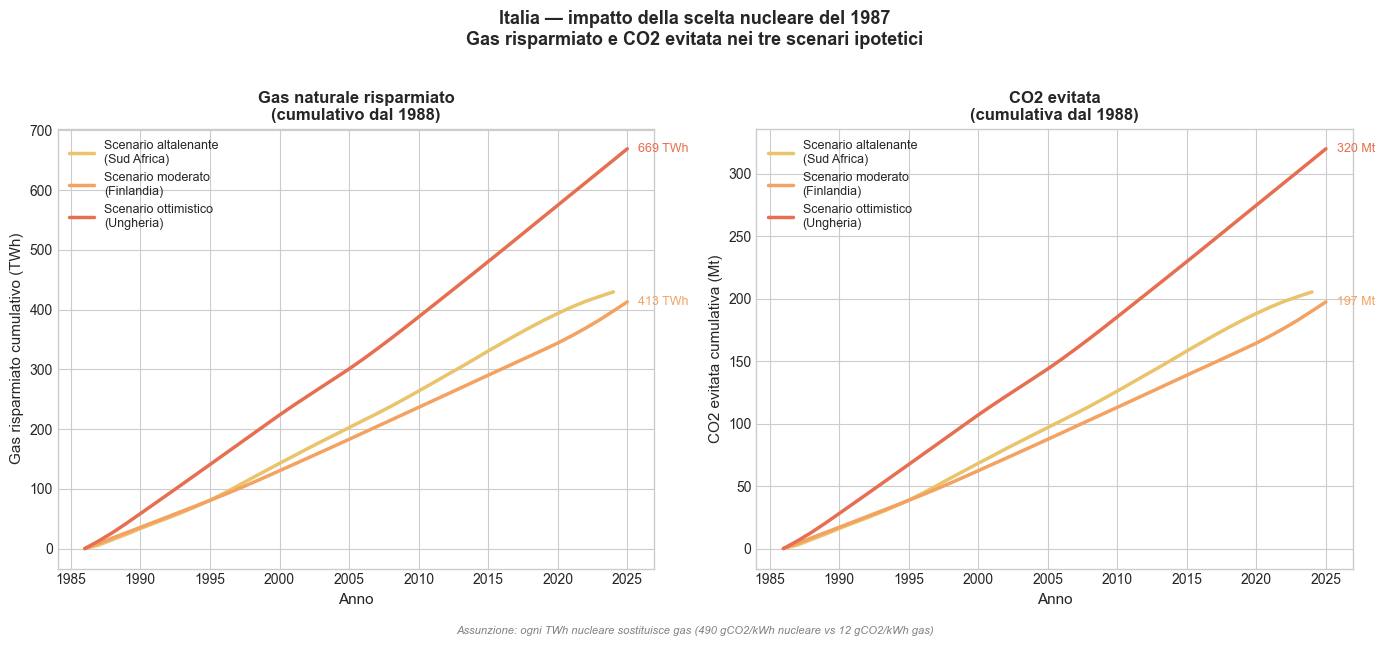

Grafico salvato in plots/


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scenari = {
    'South Africa': {'label': 'Scenario altalenante\n(Sud Africa)', 'color': '#E9C46A'},
    'Finland':      {'label': 'Scenario moderato\n(Finlandia)',     'color': '#F4A261'},
    'Hungary':      {'label': 'Scenario ottimistico\n(Ungheria)',   'color': '#E76F51'},
}

# --- Grafico sinistra: gas risparmiato cumulativo nel tempo ---
ax1 = axes[0]

for scenario, props in scenari.items():
    df_b = benchmarks_twh[scenario]
    df_calc = df_italy[['year','nuclear_twh']].merge(df_b, on='year', how='left')
    df_calc['gas_risparmiato'] = (df_calc['twh_smooth'] - df_calc['nuclear_twh']).clip(lower=0)
    df_calc['gas_cumulativo'] = df_calc['gas_risparmiato'].cumsum()
    
    ax1.plot(df_calc['year'], df_calc['gas_cumulativo'],
             color=props['color'], linewidth=2.5, label=props['label'])
    
    last = df_calc.iloc[-1]
    ax1.annotate(f"{last['gas_cumulativo']:.0f} TWh",
                xy=(last['year'], last['gas_cumulativo']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

ax1.set_xlabel('Anno', fontsize=11)
ax1.set_ylabel('Gas risparmiato cumulativo (TWh)', fontsize=11)
ax1.set_title('Gas naturale risparmiato\n(cumulativo dal 1988)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# --- Grafico destra: CO2 evitata cumulativa nel tempo ---
ax2 = axes[1]

for scenario, props in scenari.items():
    df_b = benchmarks_twh[scenario]
    df_calc = df_italy[['year','nuclear_twh']].merge(df_b, on='year', how='left')
    df_calc['gas_risparmiato'] = (df_calc['twh_smooth'] - df_calc['nuclear_twh']).clip(lower=0)
    df_calc['co2_evitata'] = df_calc['gas_risparmiato'] * 1e9 * CO2_DIFF / 1e12
    df_calc['co2_cumulativa'] = df_calc['co2_evitata'].cumsum()
    
    ax2.plot(df_calc['year'], df_calc['co2_cumulativa'],
             color=props['color'], linewidth=2.5, label=props['label'])
    
    last = df_calc.iloc[-1]
    ax2.annotate(f"{last['co2_cumulativa']:.0f} Mt",
                xy=(last['year'], last['co2_cumulativa']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('CO2 evitata cumulativa (Mt)', fontsize=11)
ax2.set_title('CO2 evitata\n(cumulativa dal 1988)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Nota metodologica
fig.text(0.5, -0.02,
         'Assunzione: ogni TWh nucleare sostituisce gas (490 gCO2/kWh nucleare vs 12 gCO2/kWh gas)',
         ha='center', fontsize=8, color='gray', style='italic')

plt.suptitle('Italia — impatto della scelta nucleare del 1987\nGas risparmiato e CO2 evitata nei tre scenari ipotetici',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../plots/06_italia_impatto_co2_gas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [25]:
# Parametri basati su dati storici documentati
# Fonte: Wikipedia, World Nuclear Association, IAEA

# Capacità installata scenario graduale (MWe)
CAORSO_MW        = 860    # già operativo
TRINO_MW         = 260    # già operativo  
MONTALTO_1_MW    = 982    # 80% completo nel 1988
MONTALTO_2_MW    = 982    # 80% completo nel 1988

# Fattore di carico medio europeo storicamente ~75%
LOAD_FACTOR = 0.75

# TWh prodotti per anno per capacità installata
# Formula: MW * ore/anno * load_factor / 1000
def twh_per_anno(mw, load_factor=LOAD_FACTOR):
    return mw * 8760 * load_factor / 1_000_000
# Produzione per impianto
twh_caorso     = twh_per_anno(CAORSO_MW)
twh_trino      = twh_per_anno(TRINO_MW)
twh_montalto_1 = twh_per_anno(MONTALTO_1_MW)
twh_montalto_2 = twh_per_anno(MONTALTO_2_MW)

print("=== Produzione annua stimata per impianto ===")
print(f"Caorso (860 MWe):         {twh_caorso:.1f} TWh/anno")
print(f"Trino (260 MWe):          {twh_trino:.1f} TWh/anno")
print(f"Montalto unità 1 (982 MWe): {twh_montalto_1:.1f} TWh/anno")
print(f"Montalto unità 2 (982 MWe): {twh_montalto_2:.1f} TWh/anno")
print(f"\nTotale con solo Montalto: {twh_caorso+twh_trino+twh_montalto_1+twh_montalto_2:.1f} TWh/anno")

# Costruiamo la traiettoria anno per anno
import numpy as np

anni = list(range(1986, 2025))
produzione = []

for anno in anni:
    if anno <= 1987:
        # Produzione reale storica
        p = df_italy[df_italy['year'] == anno]['nuclear_twh'].values
        produzione.append(float(p[0]) if len(p) > 0 else 8.76)
    
    elif anno <= 1989:
        # Transizione: Caorso e Trino ancora operativi
        # Montalto in fase finale costruzione
        p = twh_caorso + twh_trino
        # Rampa graduale verso completamento Montalto 1
        ramp = (anno - 1987) / 3
        p += twh_montalto_1 * ramp
        produzione.append(p)
    
    elif anno == 1990:
        # Montalto unità 1 operativa al 100%
        produzione.append(twh_caorso + twh_trino + twh_montalto_1)
    
    elif anno == 1991:
        # Montalto unità 2 operativa
        produzione.append(twh_caorso + twh_trino + twh_montalto_1 + twh_montalto_2)
    
    elif anno <= 2010:
        # Regime stabile — fattore di carico medio europeo
        # Trino esce di servizio intorno al 2000 (fine vita operativa)
        if anno >= 2000:
            p = twh_caorso + twh_montalto_1 + twh_montalto_2
        else:
            p = twh_caorso + twh_trino + twh_montalto_1 + twh_montalto_2
        produzione.append(p)
    
    elif anno <= 2024:
        # Post-Fukushima: riduzione 15% per manutenzioni straordinarie
        # ma nessuno spegnimento — scenario graduale
        p = (twh_caorso + twh_montalto_1 + twh_montalto_2) * 0.85
        produzione.append(p)

df_scenario = pd.DataFrame({'year': anni, 'twh_scenario': produzione})

print("\n=== Traiettoria scenario realistico ===")
for _, row in df_scenario[df_scenario['year'].isin([1987,1990,1991,2000,2010,2020,2024])].iterrows():
    print(f"  {int(row['year'])}: {row['twh_scenario']:.1f} TWh")

=== Produzione annua stimata per impianto ===
Caorso (860 MWe):         5.7 TWh/anno
Trino (260 MWe):          1.7 TWh/anno
Montalto unità 1 (982 MWe): 6.5 TWh/anno
Montalto unità 2 (982 MWe): 6.5 TWh/anno

Totale con solo Montalto: 20.3 TWh/anno

=== Traiettoria scenario realistico ===
  1987: 0.2 TWh
  1990: 13.8 TWh
  1991: 20.3 TWh
  2000: 18.6 TWh
  2010: 18.6 TWh
  2020: 15.8 TWh
  2024: 15.8 TWh


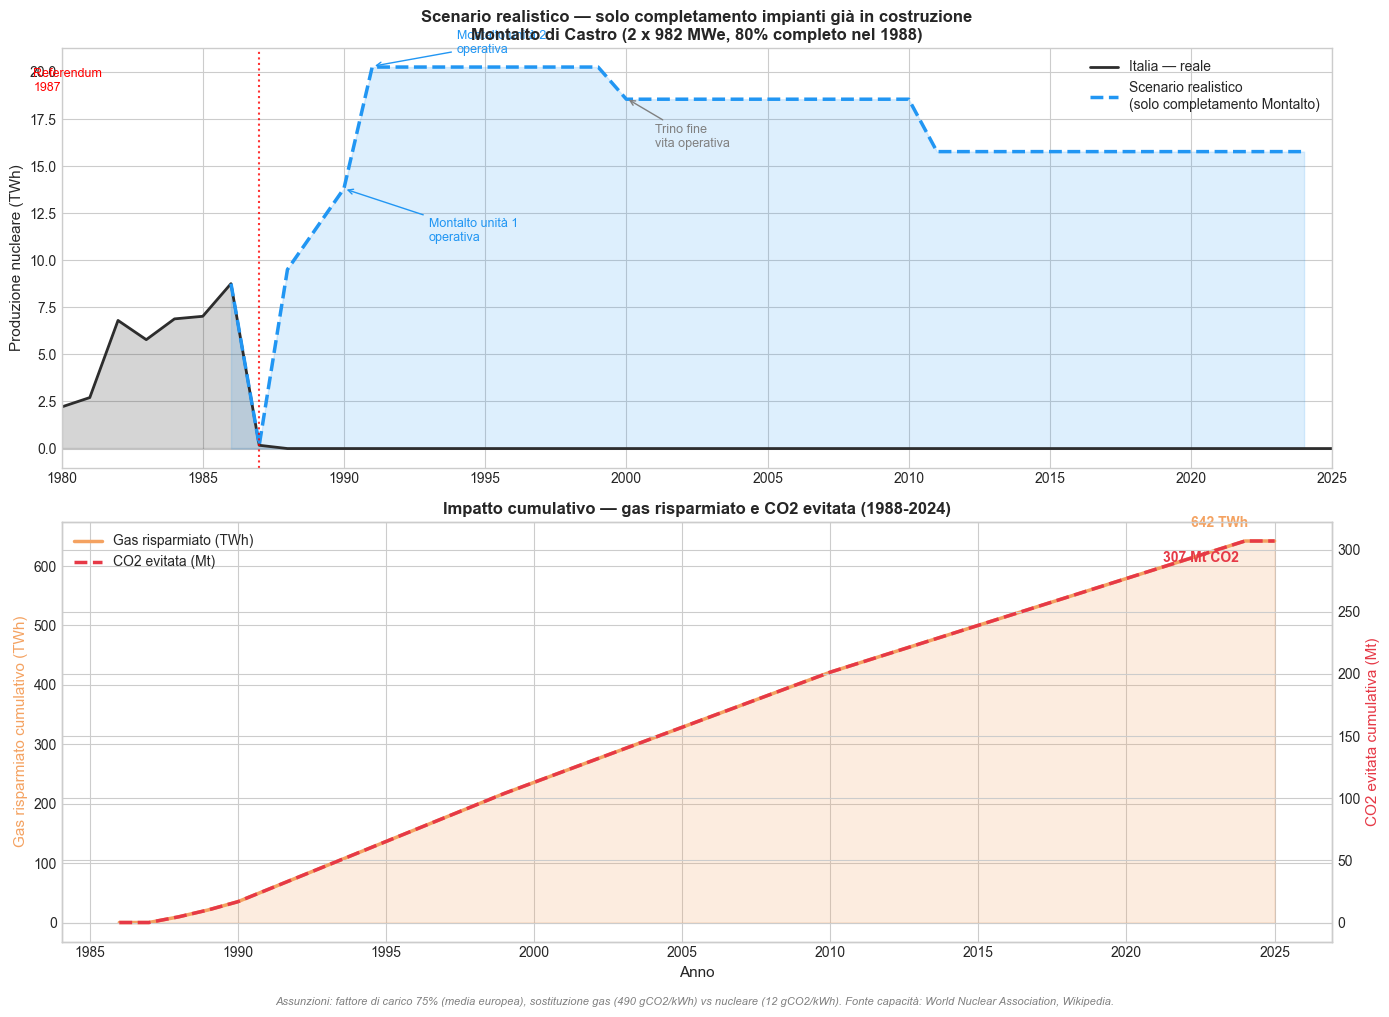

Grafico salvato in plots/


In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Grafico superiore: produzione nucleare ---
ax1 = axes[0]

df_italy_full = df_merged[df_merged['country'] == 'Italy'].copy()
ax1.fill_between(df_italy_full['year'], df_italy_full['nuclear_twh'],
                 alpha=0.2, color='#2d2d2d')
ax1.plot(df_italy_full['year'], df_italy_full['nuclear_twh'],
         color='#2d2d2d', linewidth=2, label='Italia — reale')

ax1.fill_between(df_scenario['year'], df_scenario['twh_scenario'],
                 alpha=0.15, color='#2196F3')
ax1.plot(df_scenario['year'], df_scenario['twh_scenario'],
         color='#2196F3', linewidth=2.5, linestyle='--',
         label='Scenario realistico\n(solo completamento Montalto)')

ax1.annotate('Montalto unità 1\noperativa',
             xy=(1990, 13.8), xytext=(1993, 11),
             arrowprops=dict(arrowstyle='->', color='#2196F3'),
             fontsize=9, color='#2196F3')
ax1.annotate('Montalto unità 2\noperativa',
             xy=(1991, 20.3), xytext=(1994, 21),
             arrowprops=dict(arrowstyle='->', color='#2196F3'),
             fontsize=9, color='#2196F3')
ax1.annotate('Trino fine\nvita operativa',
             xy=(2000, 18.6), xytext=(2001, 16),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color='gray')

ax1.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.text(1979, 19, 'Referendum\n1987', color='red', fontsize=9)
ax1.set_ylabel('Produzione nucleare (TWh)', fontsize=11)
ax1.set_title('Scenario realistico — solo completamento impianti già in costruzione\n'
              'Montalto di Castro (2 x 982 MWe, 80% completo nel 1988)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(1980, 2025)

# --- Grafico inferiore: impatto cumulativo ---
ax2 = axes[1]

# Merge per allineare gli anni correttamente
df_calc = df_italy_full[['year','nuclear_twh']].copy()
df_calc = df_calc[df_calc['year'] >= 1986].reset_index(drop=True)
df_calc = df_calc.merge(
    df_scenario[['year','twh_scenario']],
    on='year',
    how='left'
)
df_calc['twh_scenario'] = df_calc['twh_scenario'].fillna(0)
df_calc['gas_risparmiato'] = (df_calc['twh_scenario'] -
                               df_calc['nuclear_twh']).clip(lower=0)
df_calc['co2_evitata'] = df_calc['gas_risparmiato'] * 1e9 * CO2_DIFF / 1e12
df_calc['gas_cumulativo'] = df_calc['gas_risparmiato'].cumsum()
df_calc['co2_cumulativa'] = df_calc['co2_evitata'].cumsum()

ax2_twin = ax2.twinx()

ax2.fill_between(df_calc['year'], df_calc['gas_cumulativo'],
                 alpha=0.2, color='#F4A261')
ax2.plot(df_calc['year'], df_calc['gas_cumulativo'],
         color='#F4A261', linewidth=2.5, label='Gas risparmiato (TWh)')
ax2_twin.plot(df_calc['year'], df_calc['co2_cumulativa'],
              color='#E63946', linewidth=2.5, linestyle='--',
              label='CO2 evitata (Mt)')

last = df_calc.iloc[-1]
ax2.annotate(f"{last['gas_cumulativo']:.0f} TWh",
             xy=(last['year'], last['gas_cumulativo']),
             xytext=(-60, 10), textcoords='offset points',
             fontsize=10, color='#F4A261', fontweight='bold')
ax2_twin.annotate(f"{last['co2_cumulativa']:.0f} Mt CO2",
                  xy=(last['year'], last['co2_cumulativa']),
                  xytext=(-80, -15), textcoords='offset points',
                  fontsize=10, color='#E63946', fontweight='bold')

ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('Gas risparmiato cumulativo (TWh)', fontsize=11, color='#F4A261')
ax2_twin.set_ylabel('CO2 evitata cumulativa (Mt)', fontsize=11, color='#E63946')
ax2.set_title('Impatto cumulativo — gas risparmiato e CO2 evitata (1988-2024)',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=10)

fig.text(0.5, -0.01,
         'Assunzioni: fattore di carico 75% (media europea), '
         'sostituzione gas (490 gCO2/kWh) vs nucleare (12 gCO2/kWh). '
         'Fonte capacità: World Nuclear Association, Wikipedia.',
         ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../plots/07_italia_scenario_realistico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [28]:
# Paesi europei con parco nucleare simile all'Italia ipotetica
# Belgio, Spagna, Svezia, Finlandia — tutti con 4-6 reattori nel periodo
paesi_europei = ['Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland']

# Il fattore di carico si calcola così:
# TWh prodotti / (capacità installata MW * 8760 ore * 0.001)
# Ma noi non abbiamo la capacità installata nel dataset
# Possiamo però calcolare la crescita % anno su anno
# e usarla come riferimento per validare la nostra traiettoria

query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland')
    AND year BETWEEN 1986 AND 2024
    AND nuclear_twh > 0
    ORDER BY country, year
"""
df_eu = pd.read_sql(query, conn)

# Calcoliamo per ogni paese:
# - valore nel 1986 (punto di partenza)
# - valore massimo raggiunto
# - valore nel 2024
# - crescita % dal 1986 al massimo
risultati_eu = []
for country in paesi_europei:
    df_c = df_eu[df_eu['country'] == country]
    if len(df_c) == 0:
        continue
    val_1986 = df_c[df_c['year'] == 1986]['nuclear_twh'].values
    val_max  = df_c['nuclear_twh'].max()
    val_2024 = df_c[df_c['year'] == 2024]['nuclear_twh'].values
    anno_max = df_c.loc[df_c['nuclear_twh'].idxmax(), 'year']
    
    risultati_eu.append({
        'Paese': country,
        'TWh 1986': round(float(val_1986[0]), 1) if len(val_1986) > 0 else None,
        'TWh massimo': round(val_max, 1),
        'Anno massimo': int(anno_max),
        'TWh 2024': round(float(val_2024[0]), 1) if len(val_2024) > 0 else None,
    })

df_eu_stats = pd.DataFrame(risultati_eu)
print("=== Paesi europei di riferimento ===")
print(df_eu_stats.to_string(index=False))

# Crescita media europea dal 1986 al massimo
print(f"\nMedia TWh 1986: {df_eu_stats['TWh 1986'].mean():.1f}")
print(f"Media TWh massimo: {df_eu_stats['TWh massimo'].mean():.1f}")
print(f"Media TWh 2024: {df_eu_stats['TWh 2024'].mean():.1f}")

=== Paesi europei di riferimento ===
      Paese  TWh 1986  TWh massimo  Anno massimo  TWh 2024
    Belgium      39.4         50.3          2021      31.2
      Spain      37.5         63.7          2001      54.5
     Sweden      70.0         77.5          2004      50.7
    Finland      18.9         34.3          2023      32.6
Switzerland      22.4         27.9          2007      24.0

Media TWh 1986: 37.6
Media TWh massimo: 50.7
Media TWh 2024: 38.6


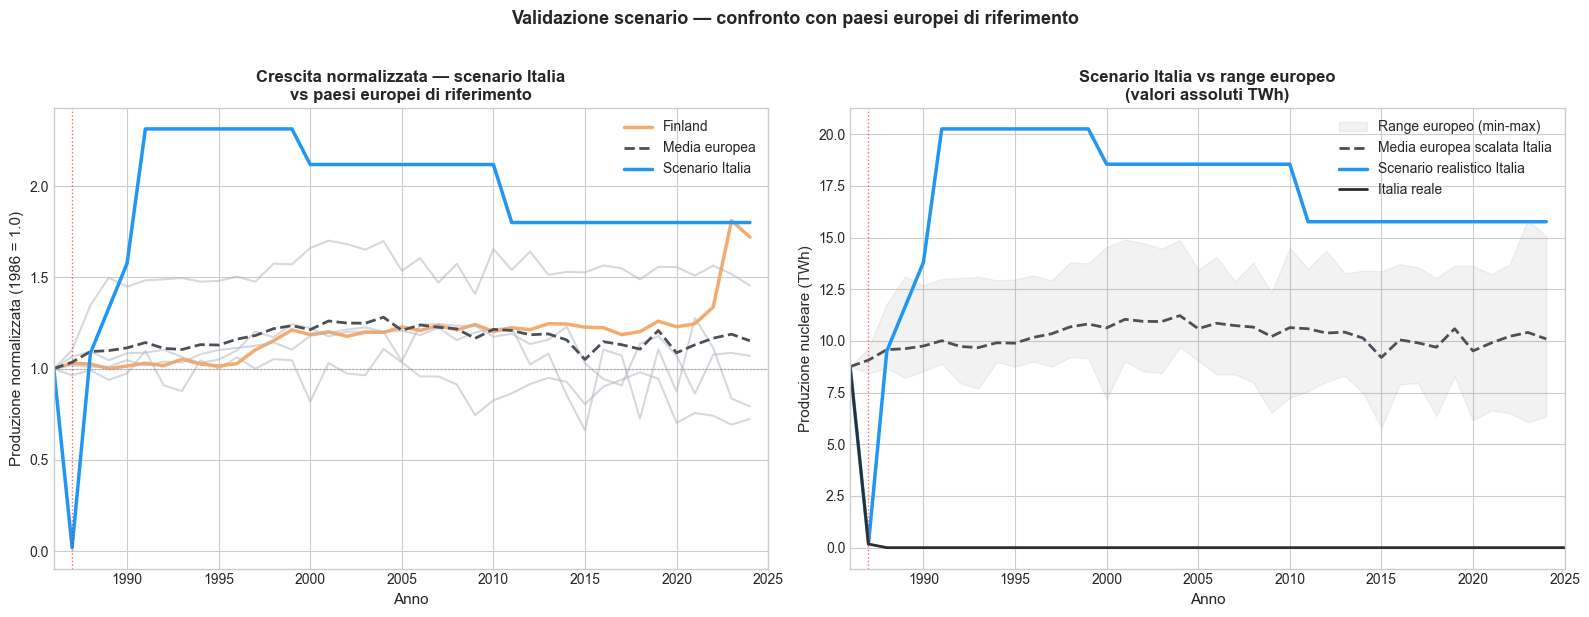

Grafico salvato in plots/


In [29]:
# Crescita normalizzata: ogni paese scala a 1.0 nel 1986
# Così confrontiamo le traiettorie indipendentemente dalla dimensione

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax2 = axes[1]

colori_eu = {
    'Belgium':     '#ADB5BD',
    'Spain':       '#ADB5BD', 
    'Sweden':      '#ADB5BD',
    'Finland':     '#F4A261',
    'Switzerland': '#ADB5BD'
}

# --- Sinistra: crescita normalizzata ---
traiettorie_normalizzate = []

for country in paesi_europei:
    df_c = df_eu[df_eu['country'] == country].copy()
    val_1986 = df_c[df_c['year'] == 1986]['nuclear_twh'].values
    if len(val_1986) == 0 or val_1986[0] == 0:
        continue
    df_c['normalizzato'] = df_c['nuclear_twh'] / val_1986[0]
    traiettorie_normalizzate.append(df_c)
    
    colore = colori_eu.get(country, '#ADB5BD')
    spessore = 2.5 if country == 'Finland' else 1.5
    alpha = 0.9 if country == 'Finland' else 0.5
    ax1.plot(df_c['year'], df_c['normalizzato'],
             color=colore, linewidth=spessore, alpha=alpha,
             label=country if country == 'Finland' else '_nolegend_')

# Media europea normalizzata
df_all_norm = pd.concat(traiettorie_normalizzate)
media_norm = df_all_norm.groupby('year')['normalizzato'].mean()
ax1.plot(media_norm.index, media_norm.values,
         color='#495057', linewidth=2, linestyle='--',
         label='Media europea')

# Scenario Italia normalizzato (base 1991 = primo anno pieno)
italy_1991 = 20.3
df_scenario_norm = df_scenario[df_scenario['year'] >= 1986].copy()
# Normalizziamo rispetto al 1986 reale italiano (8.76 TWh)
df_scenario_norm['normalizzato'] = df_scenario_norm['twh_scenario'] / 8.76
ax1.plot(df_scenario_norm['year'], df_scenario_norm['normalizzato'],
         color='#2196F3', linewidth=2.5, linestyle='-',
         label='Scenario Italia')

ax1.axvline(x=1987, color='red', linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('Anno', fontsize=11)
ax1.set_ylabel('Produzione normalizzata (1986 = 1.0)', fontsize=11)
ax1.set_title('Crescita normalizzata — scenario Italia\nvs paesi europei di riferimento',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(1986, 2025)

# --- Destra: scenario Italia con banda di confidenza europea ---
# Calcoliamo min/max della banda europea normalizzata
banda_min = df_all_norm.groupby('year')['normalizzato'].min()
banda_max = df_all_norm.groupby('year')['normalizzato'].max()

# Convertiamo in TWh assoluti per l'Italia
ax2.fill_between(banda_min.index,
                 banda_min.values * 8.76,
                 banda_max.values * 8.76,
                 alpha=0.1, color='gray',
                 label='Range europeo (min-max)')
ax2.plot(media_norm.index, media_norm.values * 8.76,
         color='#495057', linewidth=2, linestyle='--',
         label='Media europea scalata Italia')
ax2.plot(df_scenario_norm['year'], df_scenario_norm['twh_scenario'],
         color='#2196F3', linewidth=2.5,
         label='Scenario realistico Italia')

# Linea reale
df_italy_plot = df_merged[
    (df_merged['country'] == 'Italy') & 
    (df_merged['year'] >= 1986)
].copy()
ax2.plot(df_italy_plot['year'], df_italy_plot['nuclear_twh'],
         color='#2d2d2d', linewidth=2, label='Italia reale')

ax2.axvline(x=1987, color='red', linestyle=':', linewidth=1, alpha=0.6)
ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('Produzione nucleare (TWh)', fontsize=11)
ax2.set_title('Scenario Italia vs range europeo\n(valori assoluti TWh)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(1986, 2025)

plt.suptitle('Validazione scenario — confronto con paesi europei di riferimento',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../plots/08_validazione_scenario_europeo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

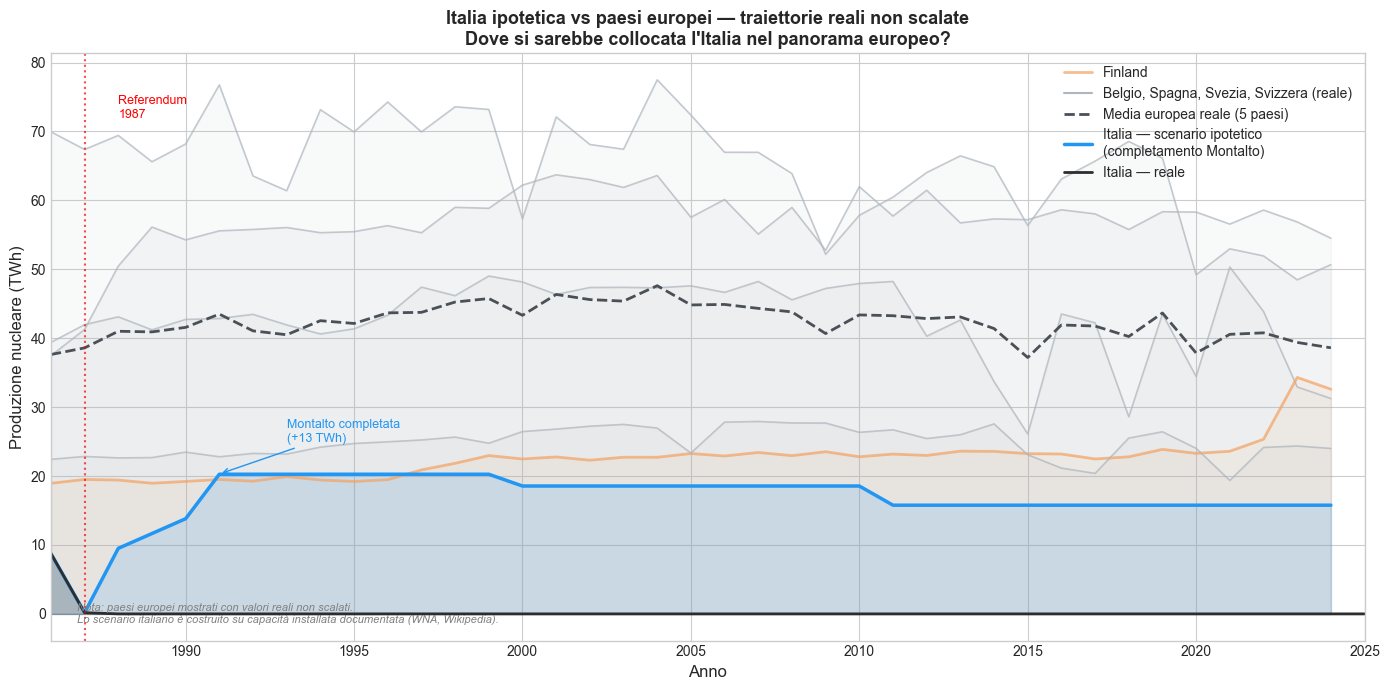

Grafico salvato in plots/


In [31]:
fig, ax = plt.subplots(figsize=(14, 7))

# Paesi europei — traiettorie reali non scalate
colori_eu = {
    'Belgium':     ('#DEE2E6', '#ADB5BD'),
    'Spain':       ('#DEE2E6', '#ADB5BD'),
    'Sweden':      ('#DEE2E6', '#ADB5BD'),
    'Finland':     ('#FFDAB9', '#F4A261'),
    'Switzerland': ('#DEE2E6', '#ADB5BD')
}

for country in paesi_europei:
    df_c = df_eu[df_eu['country'] == country].copy()
    if len(df_c) == 0:
        continue
    fill_col, line_col = colori_eu.get(country, ('#DEE2E6', '#ADB5BD'))
    spessore = 2 if country == 'Finland' else 1.2
    etichetta = country if country == 'Finland' else '_nolegend_'
    
    ax.fill_between(df_c['year'], df_c['nuclear_twh'],
                    alpha=0.08, color=line_col)
    ax.plot(df_c['year'], df_c['nuclear_twh'],
            color=line_col, linewidth=spessore,
            alpha=0.7, label=etichetta)

# Etichetta per il gruppo grigio
ax.plot([], [], color='#ADB5BD', linewidth=1.5,
        label='Belgio, Spagna, Svezia, Svizzera (reale)')

# Media europea reale
media_eu_reale = df_eu.groupby('year')['nuclear_twh'].mean()
ax.plot(media_eu_reale.index, media_eu_reale.values,
        color='#495057', linewidth=2, linestyle='--',
        label='Media europea reale (5 paesi)')

# Scenario Italia ipotetico — valori assoluti
ax.fill_between(df_scenario['year'], df_scenario['twh_scenario'],
                alpha=0.15, color='#2196F3')
ax.plot(df_scenario['year'], df_scenario['twh_scenario'],
        color='#2196F3', linewidth=2.5,
        label='Italia — scenario ipotetico\n(completamento Montalto)')

# Italia reale
df_italy_plot = df_merged[
    (df_merged['country'] == 'Italy') &
    (df_merged['year'] >= 1986)
].copy()
ax.fill_between(df_italy_plot['year'], df_italy_plot['nuclear_twh'],
                alpha=0.2, color='#2d2d2d')
ax.plot(df_italy_plot['year'], df_italy_plot['nuclear_twh'],
        color='#2d2d2d', linewidth=2,
        label='Italia — reale')

# Linea referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1988, 72, 'Referendum\n1987', color='red', fontsize=9)

# Annotazione Montalto
ax.annotate('Montalto completata\n(+13 TWh)',
            xy=(1991, 20.3), xytext=(1993, 25),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Italia ipotetica vs paesi europei — traiettorie reali non scalate\n'
             'Dove si sarebbe collocata l\'Italia nel panorama europeo?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(1986, 2025)

# Nota metodologica
ax.text(0.02, 0.03,
        'Nota: paesi europei mostrati con valori reali non scalati.\n'
        'Lo scenario italiano è costruito su capacità installata documentata (WNA, Wikipedia).',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../plots/08_confronto_europeo_reale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [32]:
query = """
    SELECT n.country, n.year, 
           n.nuclear_twh,
           i.nuclear_share_elec
    FROM nuclear_generation n
    LEFT JOIN nuclear_indicators i 
        ON n.country = i.country AND n.year = i.year
    WHERE n.country IN ('Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland')
    AND n.year BETWEEN 1986 AND 2024
    AND n.nuclear_twh > 0
    ORDER BY n.country, n.year
"""
df_eu_share = pd.read_sql(query, conn)

print("=== Disponibilità dati quota % per paese ===")
for country in ['Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland']:
    df_c = df_eu_share[df_eu_share['country'] == country]
    dati_share = df_c['nuclear_share_elec'].notna().sum()
    print(f"{country}: {dati_share} anni con dati quota %")

print("\nPrime righe Finlandia:")
print(df_eu_share[df_eu_share['country'] == 'Finland'].head(10))

=== Disponibilità dati quota % per paese ===
Belgium: 39 anni con dati quota %
Spain: 39 anni con dati quota %
Sweden: 39 anni con dati quota %
Finland: 39 anni con dati quota %
Switzerland: 39 anni con dati quota %

Prime righe Finlandia:
    country  year  nuclear_twh  nuclear_share_elec
39  Finland  1986    18.945263              38.705
40  Finland  1987    19.509474              36.799
41  Finland  1988    19.417894              36.301
42  Finland  1989    18.957895              35.529
43  Finland  1990    19.220000              35.357
44  Finland  1991    19.510000              33.661
45  Finland  1992    19.260000              33.380
46  Finland  1993    19.930000              32.640
47  Finland  1994    19.430000              29.610
48  Finland  1995    19.220000              30.031


In [33]:
# Produzione elettrica totale Italia dal CSV OWID
df_it_elec = df_owid_full[df_owid_full['country'] == 'Italy'][
    ['year', 'electricity_generation']
].copy()
df_it_elec = df_it_elec[df_it_elec['year'] >= 1986].copy()

# Uniamo con lo scenario ipotetico
df_italy_share = df_scenario.merge(df_it_elec, on='year', how='left')
df_italy_share['share_ipotetica'] = (
    df_italy_share['twh_scenario'] / 
    df_italy_share['electricity_generation'] * 100
)

# Quota reale italiana
df_italy_real_share = pd.read_sql("""
    SELECT i.year, i.nuclear_share_elec
    FROM nuclear_indicators i
    WHERE i.country = 'Italy'
    AND i.year BETWEEN 1986 AND 2024
""", conn)

print("=== Quota % ipotetica Italia ===")
for _, row in df_italy_share[
    df_italy_share['year'].isin([1986,1991,1995,2000,2010,2020,2024])
].iterrows():
    print(f"  {int(row['year'])}: {row['share_ipotetica']:.1f}%")

=== Quota % ipotetica Italia ===
  1986: 4.6%
  1991: 9.3%
  1995: 8.5%
  2000: 6.9%
  2010: 6.3%
  2020: 5.7%
  2024: 5.9%


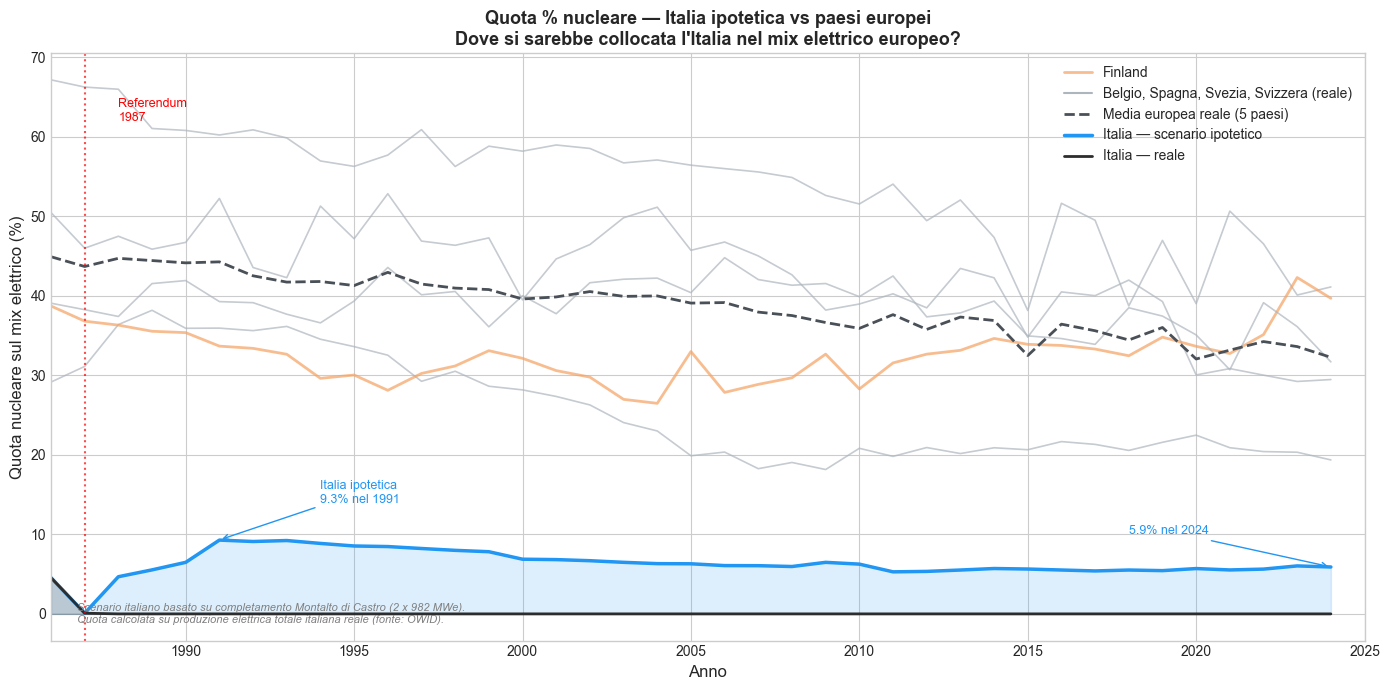

Grafico salvato in plots/


In [35]:
fig, ax = plt.subplots(figsize=(14, 7))

colori_eu = {
    'Belgium':     '#ADB5BD',
    'Spain':       '#ADB5BD',
    'Sweden':      '#ADB5BD',
    'Finland':     '#F4A261',
    'Switzerland': '#ADB5BD'
}

for country in ['Belgium', 'Spain', 'Sweden', 'Finland', 'Switzerland']:
    df_c = df_eu_share[df_eu_share['country'] == country].copy()
    colore = colori_eu[country]
    spessore = 2 if country == 'Finland' else 1.2
    etichetta = country if country == 'Finland' else '_nolegend_'

    ax.plot(df_c['year'], df_c['nuclear_share_elec'],
            color=colore, linewidth=spessore,
            alpha=0.7, label=etichetta)

ax.plot([], [], color='#ADB5BD', linewidth=1.5,
        label='Belgio, Spagna, Svezia, Svizzera (reale)')

media_share_eu = df_eu_share.groupby('year')['nuclear_share_elec'].mean()
ax.plot(media_share_eu.index, media_share_eu.values,
        color='#495057', linewidth=2, linestyle='--',
        label='Media europea reale (5 paesi)')

ax.fill_between(df_italy_share['year'],
                df_italy_share['share_ipotetica'].fillna(0),
                alpha=0.15, color='#2196F3')
ax.plot(df_italy_share['year'],
        df_italy_share['share_ipotetica'].fillna(0),
        color='#2196F3', linewidth=2.5,
        label='Italia — scenario ipotetico')

ax.fill_between(df_italy_real_share['year'],
                df_italy_real_share['nuclear_share_elec'].fillna(0),
                alpha=0.2, color='#2d2d2d')
ax.plot(df_italy_real_share['year'],
        df_italy_real_share['nuclear_share_elec'].fillna(0),
        color='#2d2d2d', linewidth=2,
        label='Italia — reale')

ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1988, 62, 'Referendum\n1987', color='red', fontsize=9)

ax.annotate('Italia ipotetica\n9.3% nel 1991',
            xy=(1991, 9.3), xytext=(1994, 14),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

ax.annotate('5.9% nel 2024',
            xy=(2024, 5.9), xytext=(2018, 10),
            arrowprops=dict(arrowstyle='->', color='#2196F3'),
            fontsize=9, color='#2196F3')

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Quota nucleare sul mix elettrico (%)', fontsize=12)
ax.set_title('Quota % nucleare — Italia ipotetica vs paesi europei\n'
             'Dove si sarebbe collocata l\'Italia nel mix elettrico europeo?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(1986, 2025)

ax.text(0.02, 0.03,
        'Scenario italiano basato su completamento Montalto di Castro (2 x 982 MWe).\n'
        'Quota calcolata su produzione elettrica totale italiana reale (fonte: OWID).',
        transform=ax.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../plots/09_quota_nucleare_confronto_europeo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")